## Scientific Context: Extreme Value Analysis and Resultant Wind Speed

Extreme value analysis relies on the acquisition of high-quality long-term meteorological data. Because extreme wind events are rare, short-term observational datasets are generally insufficient for modeling future return levels. This study utilises long-term historical wind speed data spanning several decades to ensure statistical reliability.

The resulting wind speed was calculated by summing up the two wind speeds and performing Pythagoras Theorem

$$\begin{equation}
    V_{\text{res}} = \sqrt{u_{\text{wind}}^2 + v_{\text{wind}}^2}
\end{equation}$$

where

*   $V_{res}$ is the resultant wind speed magnitude in m/s.
*   $u_{\text{wind}}$ is the 10m u-components of the wind in the eastward directions
*   $v_{\text{wind}}$ is the 10m v-components of the wind in the northward directions

## Seasonal Wind Speed Boxplots

### Combined Wind Speed Extrapolation

To account for vertical wind shear, wind speed data recorded at a reference height ($z_{ref}$) must be extrapolated to the turbine hub heights ($z$). This study utilizes a combined approach, averaging both the Wind Profile Power Law and the Logarithmic Wind Profile Law.

**1. Wind Profile Power Law ($v_{PL}$):**

$$v_{PL} = v_{ref} \left(\frac{z}{z_{ref}}\right)^{\alpha}$$

Where:
- $v_{ref}$: Wind speed at reference height $z_{ref}$.
- $z$: Target hub height.
- $z_{ref}$: Reference height (e.g., 10 m).
- $\alpha$: Surface friction coefficient (Hellmann exponent), typically 0.14 for open flat terrain.

**2. Logarithmic Wind Profile Law ($v_{LL}$):**

$$v_{LL} = v_{ref} \frac{\ln(z/z_0)}{\ln(z_{ref}/z_0)}$$

Where:
- $z_0$: Surface roughness length.

**3. Combined Final Wind Speed ($v_{final}$):**

The hub-height wind speed is taken as the arithmetic average of both methods:

$$v_{final} = \frac{v_{PL} + v_{LL}}{2}$$

For this calculation, we will use $\alpha = 0.14$ and $z_0 = 0.03$ m (a typical value for open country).

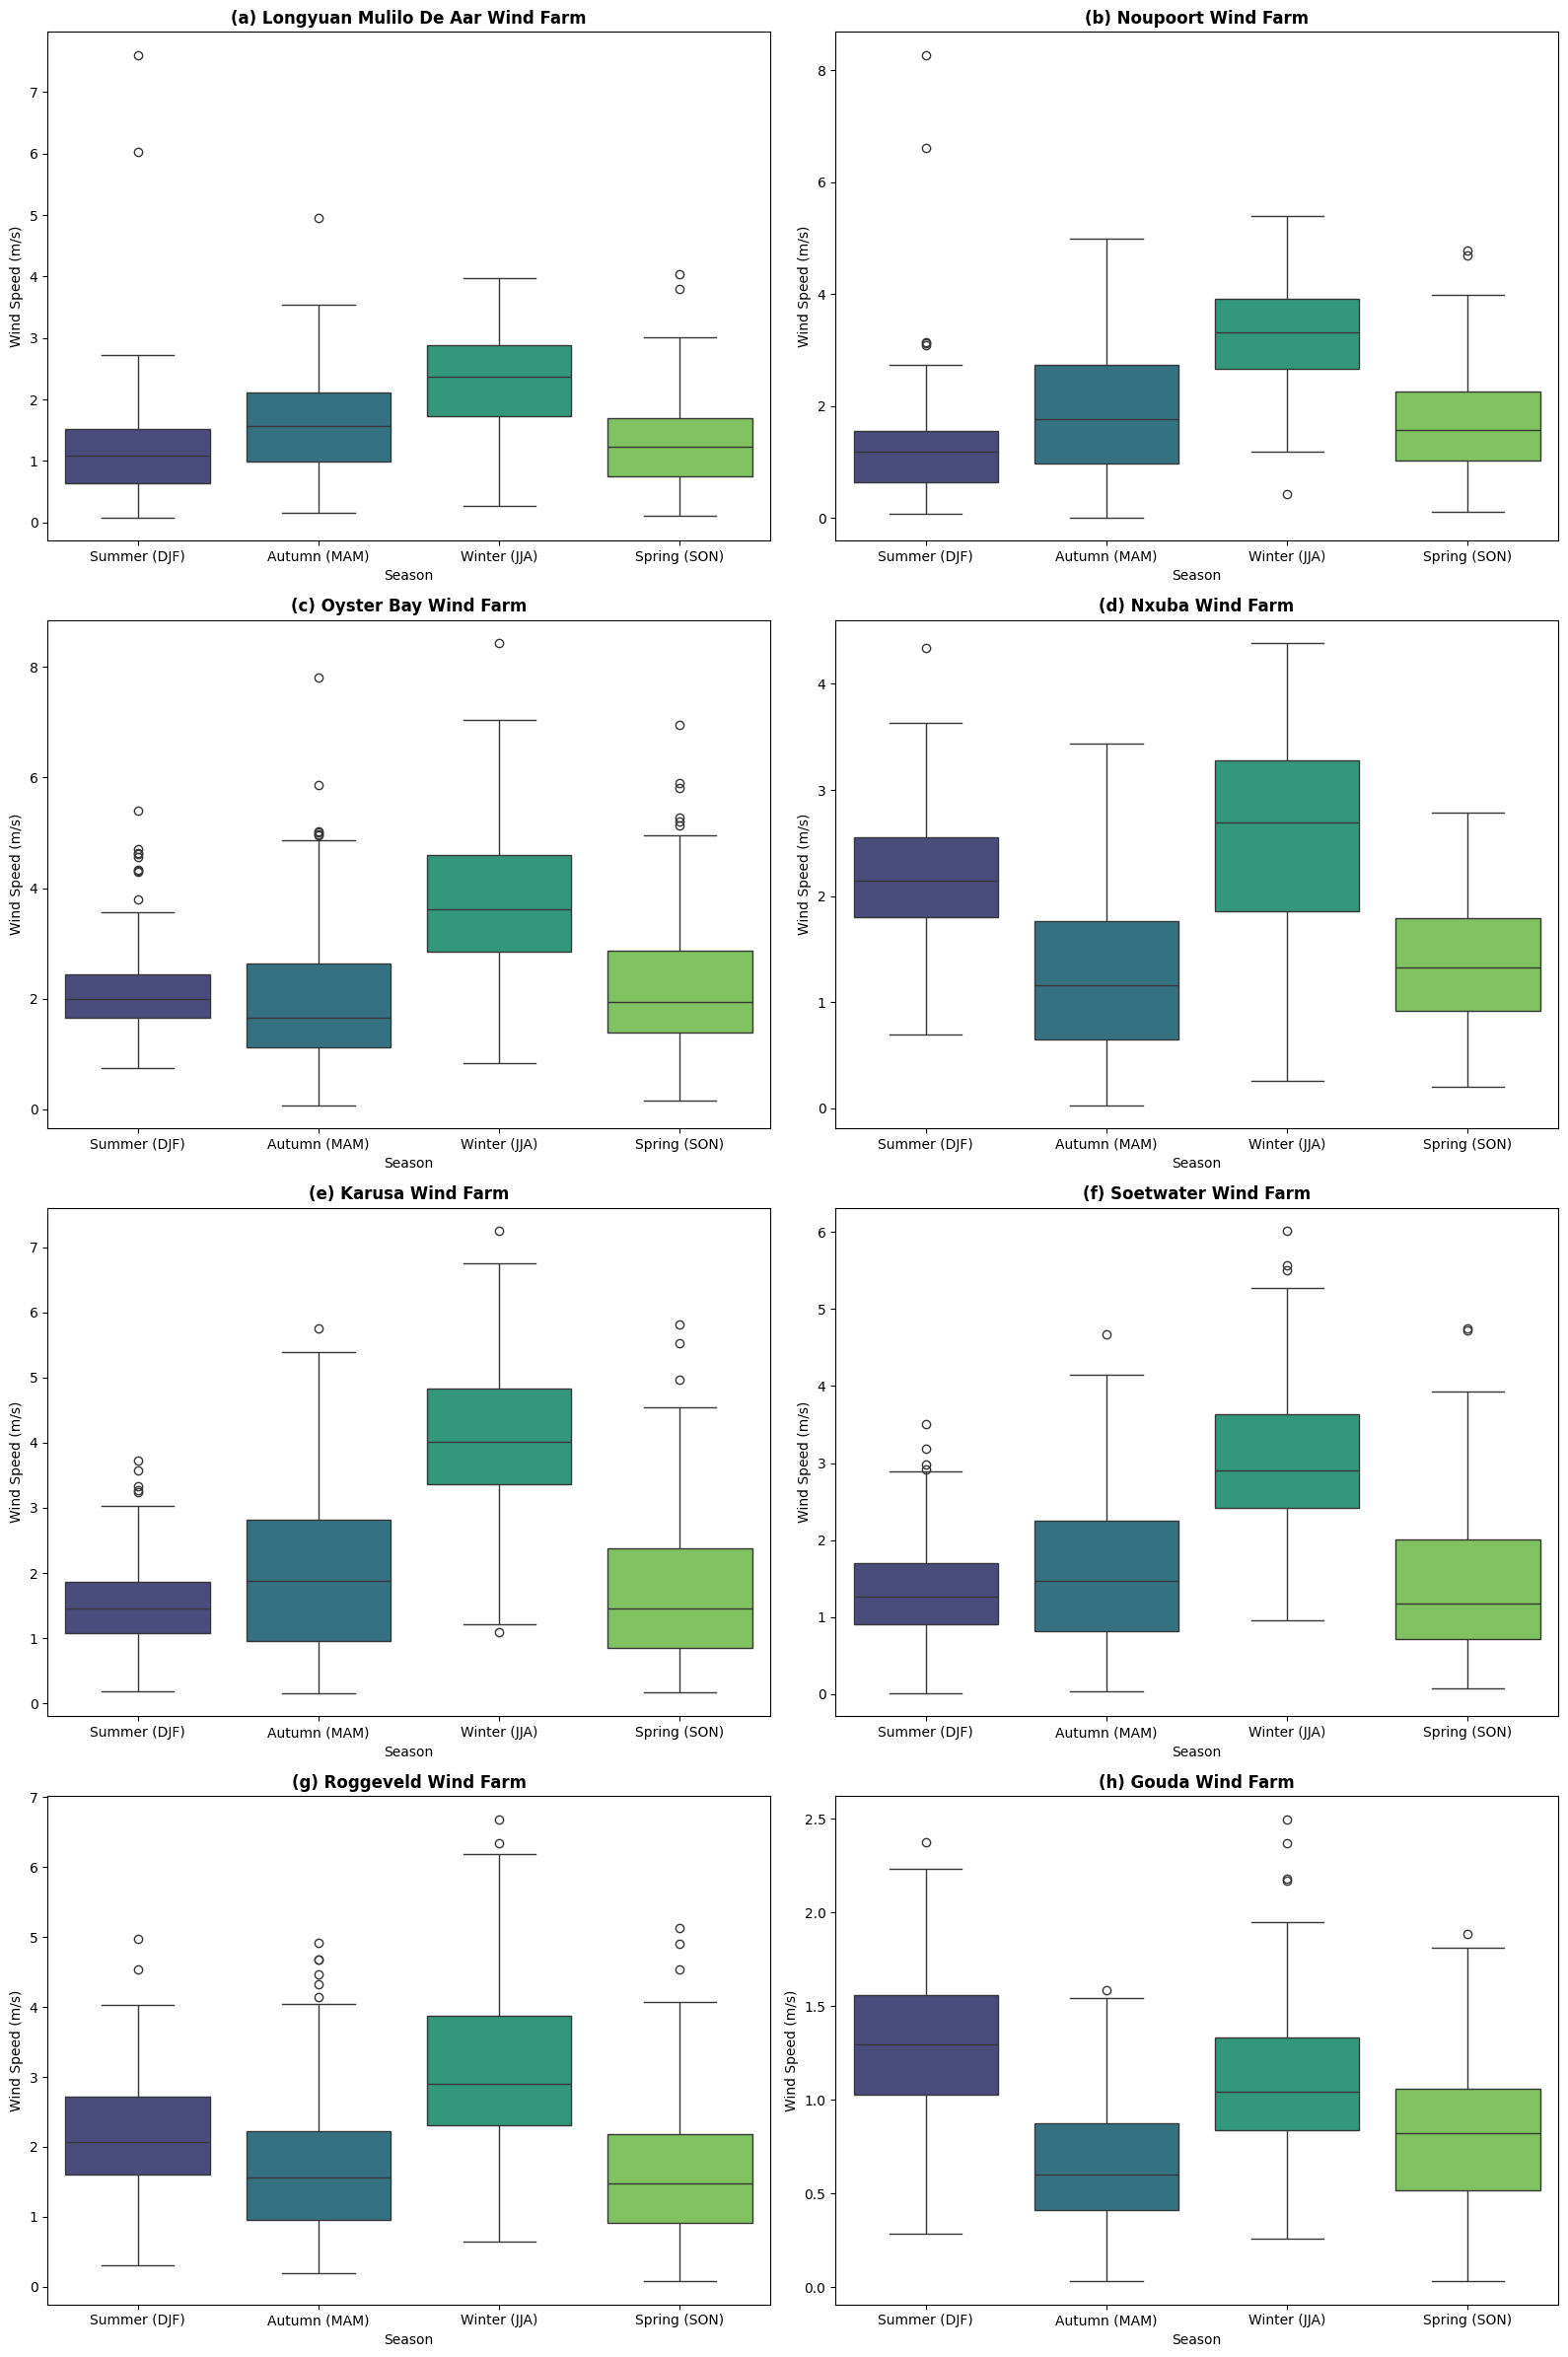

In [15]:
import xarray as xr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def dms_to_decimal(dms_str):
    parts = dms_str.replace('◦', ' ').replace('′', ' ').strip().split()
    degrees = float(parts[0])
    minutes = float(parts[1])
    decimal = degrees + minutes / 60
    if 'S' in dms_str or 'W' in dms_str: decimal *= -1
    return decimal

wind_farms_data = [
    {"Wind Farm": "Longyuan Mulilo De Aar", "Latitude_DMS": "30◦39′S", "Longitude_DMS": "24◦01′E", "Hub Ht. (m)": 80.0},
    {"Wind Farm": "Noupoort Wind Farm", "Latitude_DMS": "31◦11′S", "Longitude_DMS": "24◦56′E", "Hub Ht. (m)": 99.5},
    {"Wind Farm": "Oyster Bay Wind Farm", "Latitude_DMS": "34◦10′S", "Longitude_DMS": "24◦39′E", "Hub Ht. (m)": 91.5},
    {"Wind Farm": "Nxuba Wind Farm", "Latitude_DMS": "32◦44′S", "Longitude_DMS": "25◦56′E", "Hub Ht. (m)": 100.0},
    {"Wind Farm": "Karusa Wind Farm", "Latitude_DMS": "32◦50′S", "Longitude_DMS": "20◦41′E", "Hub Ht. (m)": 112.0},
    {"Wind Farm": "Soetwater Wind Farm", "Latitude_DMS": "32◦45′S", "Longitude_DMS": "20◦37′E", "Hub Ht. (m)": 112.0},
    {"Wind Farm": "Roggeveld Wind Farm", "Latitude_DMS": "32◦57′S", "Longitude_DMS": "20◦32′E", "Hub Ht. (m)": 100.0},
    {"Wind Farm": "Gouda Wind Farm", "Latitude_DMS": "33◦00′S", "Longitude_DMS": "19◦16′E", "Hub Ht. (m)": 100.0}
]

for wf in wind_farms_data:
    wf['Latitude'], wf['Longitude'] = dms_to_decimal(wf['Latitude_DMS']), dms_to_decimal(wf['Longitude_DMS'])

try: ds = xr.open_dataset('/content/ERA5.nc')
except FileNotFoundError:
    dummy_times = pd.date_range('2000-01-01', periods=24, freq='MS')
    ds = xr.Dataset({"u100": (("time", "latitude", "longitude"), np.random.rand(24, 10, 15)), "v100": (("time", "latitude", "longitude"), np.random.rand(24, 10, 15))}, coords={"time": dummy_times, "latitude": np.arange(-35, -25), "longitude": np.arange(15, 30)})

ref_h = 100.0 if 'u100' in ds else 10.0
ws_ref = np.sqrt(ds.get('u100', ds.get('u10'))**2 + ds.get('v100', ds.get('v10'))**2)

final_df = pd.concat([pd.DataFrame({'Time': ds['valid_time'].values, 'Wind Speed (m/s)': ws_ref.sel(latitude=wf['Latitude'], longitude=wf['Longitude'], method='nearest').values * ((wf['Hub Ht. (m)']/ref_h)**0.14 + (np.log(wf['Hub Ht. (m)']/0.03)/np.log(ref_h/0.03)))/2, 'Wind Farm': wf['Wind Farm'], 'Season': [(['Summer (DJF)', 'Autumn (MAM)', 'Winter (JJA)', 'Spring (SON)'][(m%12)//3]) for m in ds['valid_time'].dt.month.values]}) for wf in wind_farms_data])

plt.figure(figsize=(16, 24))
for i, farm in enumerate(final_df['Wind Farm'].unique()):
    plt.subplot(4, 2, i+1)
    sns.boxplot(data=final_df[final_df['Wind Farm']==farm], x='Season', y='Wind Speed (m/s)', palette='viridis', hue='Season', legend=False)
    plt.title(f'({chr(97+i)}) {farm if "Wind Farm" in farm else farm + " Wind Farm"}', fontweight='bold')
plt.tight_layout(); plt.show()

In [15]:
# Save the figure as a PNG file with high resolution
plt.savefig('seasonal_wind_speed_boxplots.png', dpi=300, bbox_inches='tight')
print("Plot saved as 'seasonal_wind_speed_boxplots.png' in your Colab environment.")

Plot saved as 'seasonal_wind_speed_boxplots.png' in your Colab environment.


<Figure size 640x480 with 0 Axes>

### Annual Maxima Time Series per Wind Farm
This section visualizes the peak wind speed recorded each year for each individual farm.

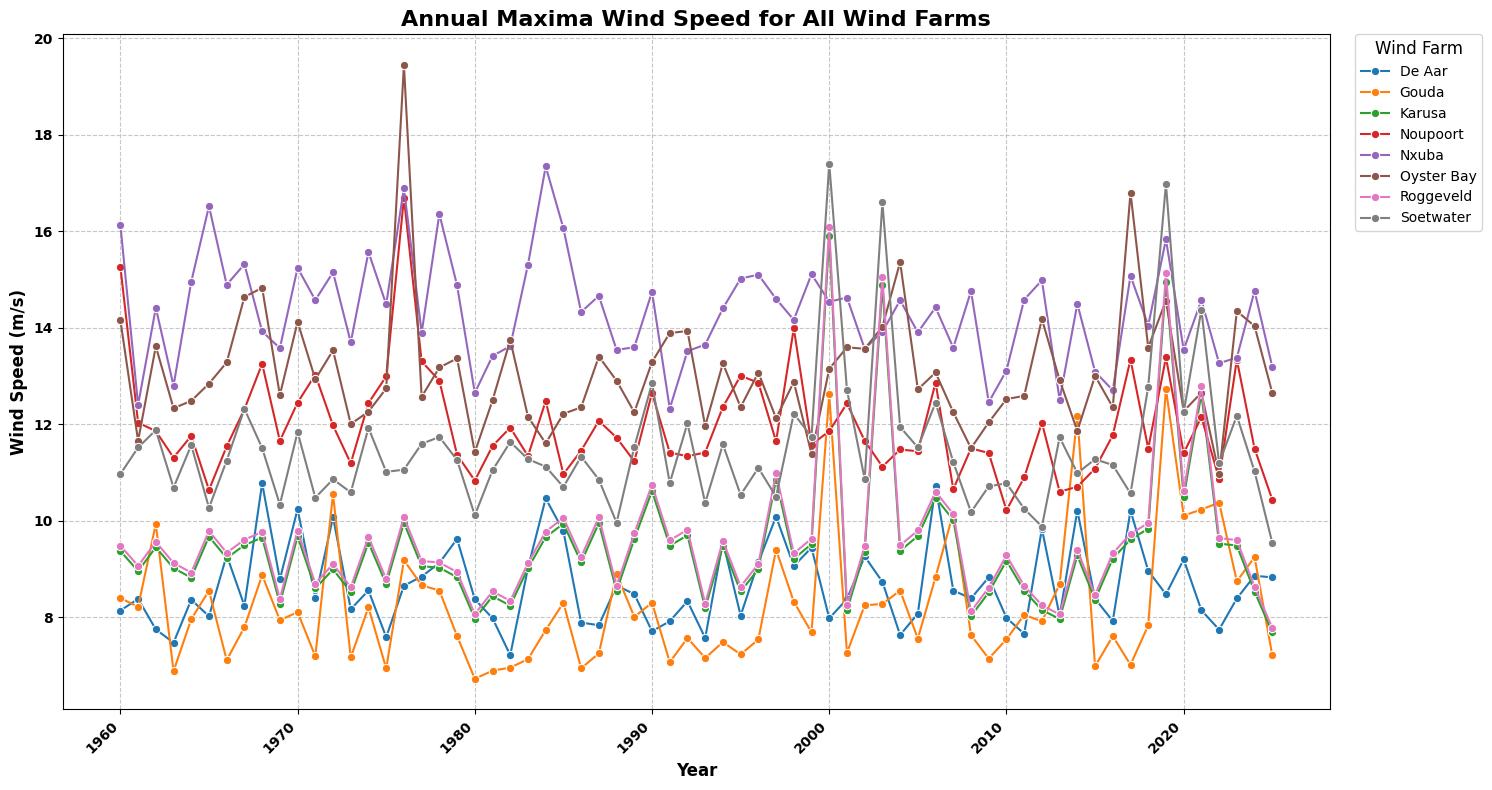

In [13]:
# Load the Annual Maxima Wind Speed data
try:
    annual_maxima_df = pd.read_csv('/content/Annual_Maxima_HubHeight.csv')
except FileNotFoundError:
    print("Error: Annual_Maxima_HubHeight.csv not found. Please ensure the file is uploaded.")
    # Generate dummy data for demonstration if file not found
    dummy_data = []
    for farm in wind_farm_names:
        for year in range(1960, 2026):
            dummy_data.append({
                'Wind Farm': farm,
                'Year': year,
                'Wind Speed (m/s)': np.random.uniform(5, 20) # Random maxima between 5 and 20 m/s
            })
    annual_maxima_df = pd.DataFrame(dummy_data)

# Ensure 'Year' is numeric
annual_maxima_df['Year'] = pd.to_numeric(annual_maxima_df['Year'])

# Melt the DataFrame to have 'Wind Farm' and 'Wind Speed (m/s)' columns for plotting
# The columns containing wind speeds are all columns except 'Year'
wind_farm_columns = [col for col in annual_maxima_df.columns if col != 'Year']
melted_annual_maxima_df = annual_maxima_df.melt(
    id_vars=['Year'],
    value_vars=wind_farm_columns,
    var_name='Wind Farm',
    value_name='Wind Speed (m/s)'
)

# Ensure 'Wind Speed (m/s)' is numeric in the melted DataFrame
melted_annual_maxima_df['Wind Speed (m/s)'] = pd.to_numeric(melted_annual_maxima_df['Wind Speed (m/s)'])

plt.figure(figsize=(15, 8))

sns.lineplot(
    data=melted_annual_maxima_df,
    x='Year',
    y='Wind Speed (m/s)',
    hue='Wind Farm',  # Use 'Wind Farm' for different colors
    palette='tab10',  # A good palette for distinguishing multiple lines
    marker='o',       # Keep markers for individual data points
    linestyle='-'     # Solid line style
)

plt.title('Annual Maxima Wind Speed for All Wind Farms', fontsize=16, fontweight='bold')
plt.xlabel('Year', fontsize=12, fontweight='bold')
plt.ylabel('Wind Speed (m/s)', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontweight='bold')
plt.yticks(fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='Wind Farm', bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0., fontsize=10, title_fontsize=12)
plt.tight_layout()
plt.show()

### Monthly Maxima Wind Speed for All Wind Farms

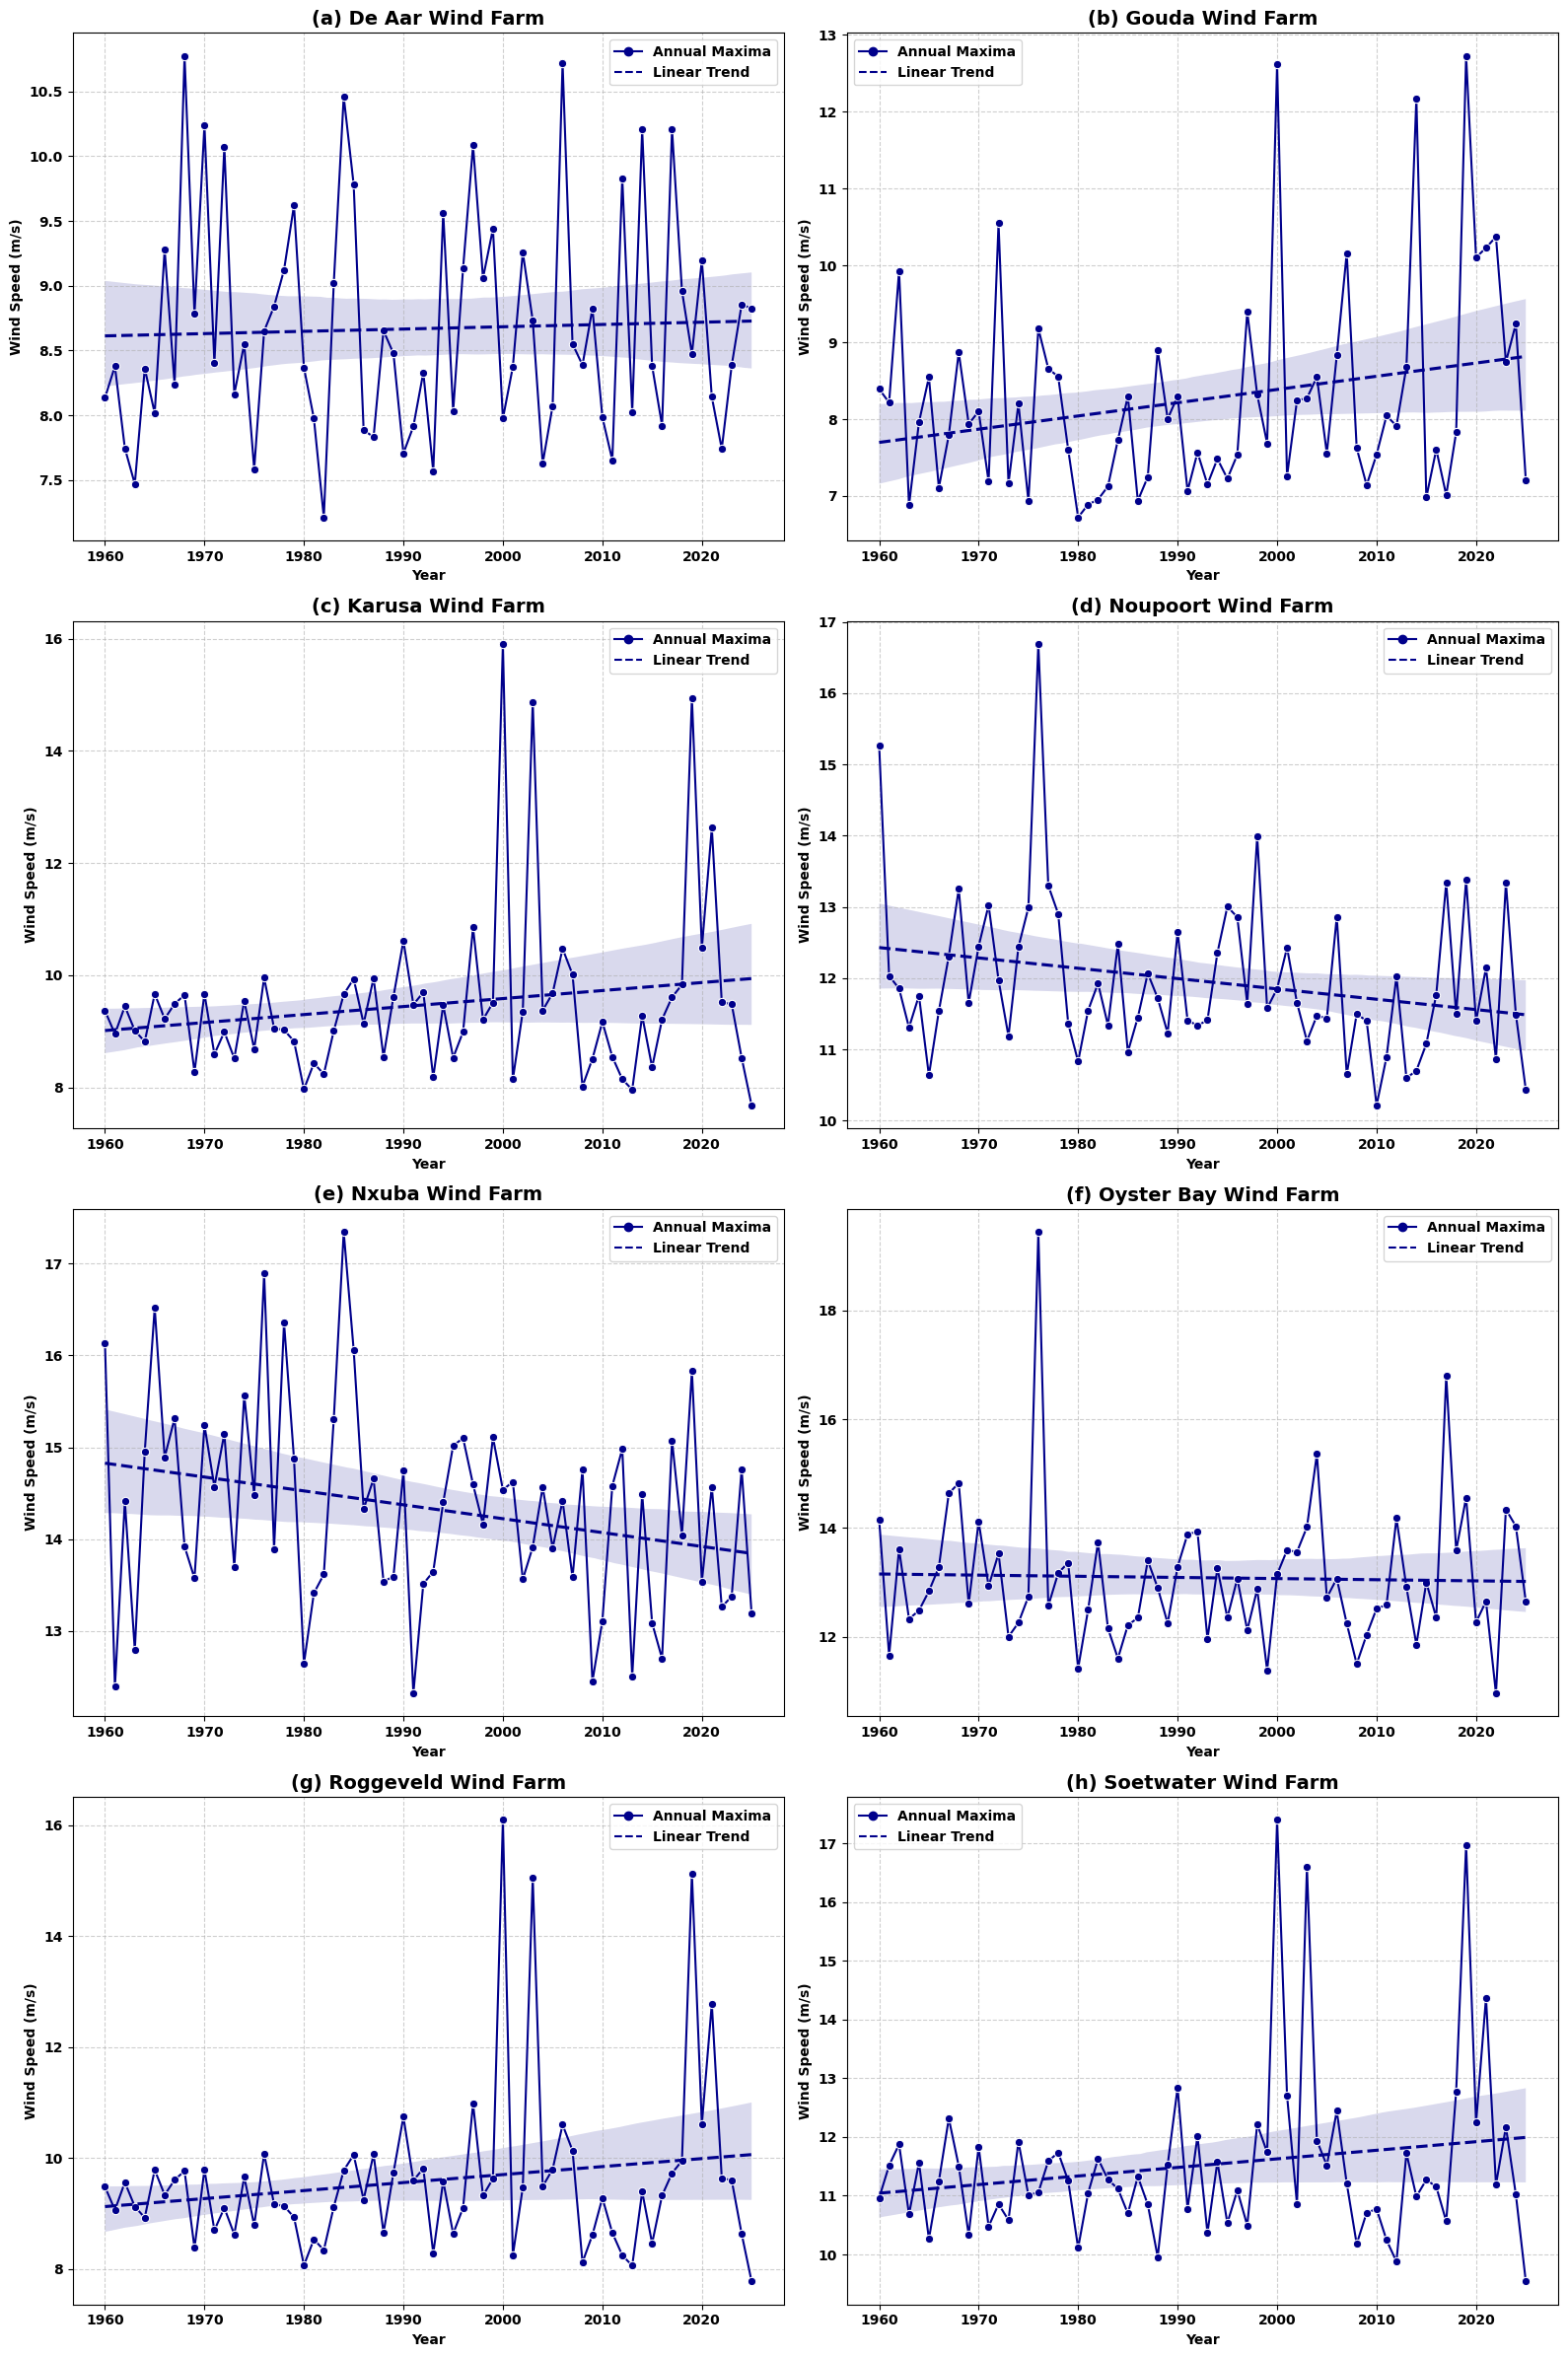

In [25]:
import matplotlib.lines as mlines
import matplotlib.pyplot as plt
import seaborn as sns

fams = melted_annual_maxima_df['Wind Farm'].unique()
plt.figure(figsize=(16, 24))
for i, farm in enumerate(fams):
    ax = plt.subplot(4, 2, i+1)
    data = melted_annual_maxima_df[melted_annual_maxima_df['Wind Farm'] == farm]

    # Plot Annual Maxima with original darkblue circular markers
    sns.lineplot(x='Year', y='Wind Speed (m/s)', data=data, color='darkblue', marker='o', ax=ax)

    # Add linear trend line
    sns.regplot(x='Year', y='Wind Speed (m/s)', data=data, scatter=False, color='darkblue', line_kws={'ls':'--'}, ax=ax)

    # Consistent naming and bold formatting
    title_name = farm if "Wind Farm" in farm else f"{farm} Wind Farm"
    plt.title(f'({chr(97+i)}) {title_name}', fontsize=14, fontweight='bold')

    plt.xlabel('Year', fontweight='bold')
    plt.ylabel('Wind Speed (m/s)', fontweight='bold')
    plt.xticks(fontweight='bold')
    plt.yticks(fontweight='bold')
    plt.grid(True, linestyle='--', alpha=0.6)

    # Add custom legend with bold font
    data_line = mlines.Line2D([], [], color='darkblue', marker='o', label='Annual Maxima')
    trend_line = mlines.Line2D([], [], color='darkblue', linestyle='--', label='Linear Trend')
    ax.legend(handles=[data_line, trend_line], loc='best', prop={'weight': 'bold'})

plt.tight_layout()
plt.show()

### Monthly Maxima Time Series per Wind Farm
This section visualizes the seasonal peaks (monthly averages of maxima) for each farm.

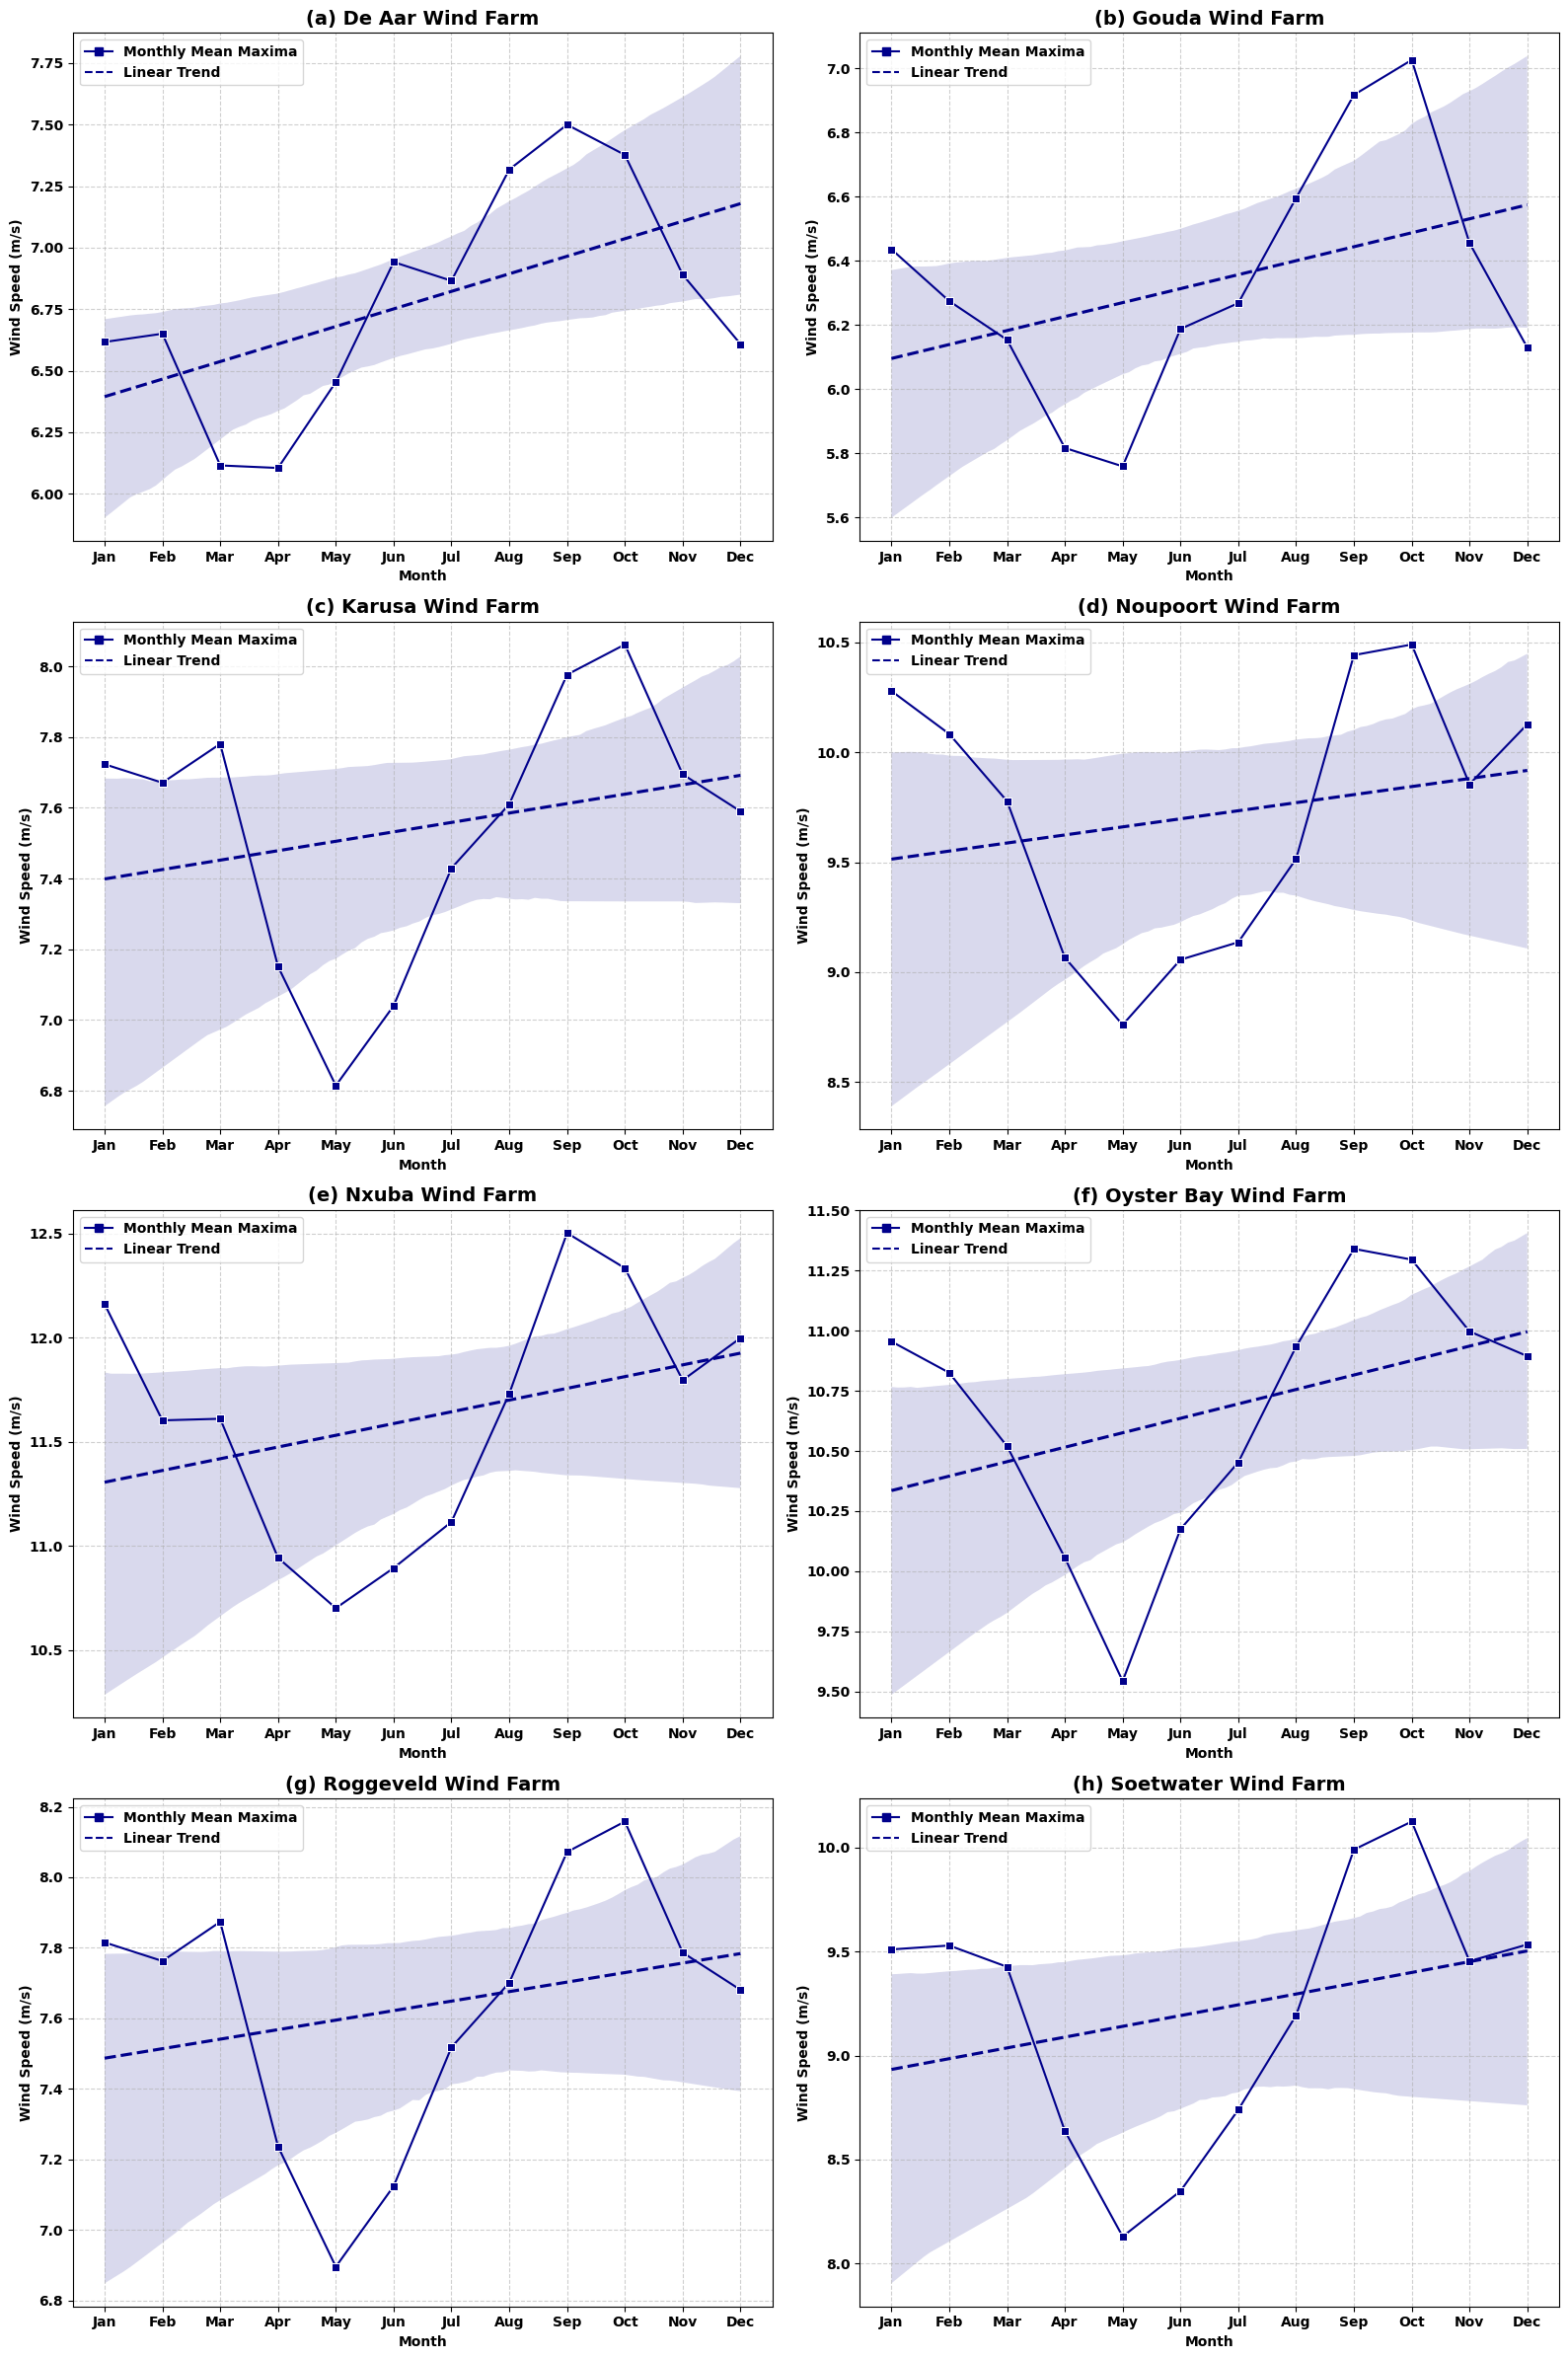

In [22]:
import matplotlib.lines as mlines
import matplotlib.pyplot as plt
import seaborn as sns

fams = monthly_maxima_mean_wind_speed['Wind Farm'].unique()
plt.figure(figsize=(16, 24))
for i, farm in enumerate(fams):
    ax = plt.subplot(4, 2, i+1)
    data = monthly_maxima_mean_wind_speed[monthly_maxima_mean_wind_speed['Wind Farm'] == farm]

    # Plot the monthly mean maxima with the original darkblue square markers
    sns.lineplot(x='Month', y='Wind Speed (m/s)', data=data, color='darkblue', marker='s', ax=ax)

    # Add the linear trend line
    sns.regplot(x='Month', y='Wind Speed (m/s)', data=data, scatter=False, color='darkblue', line_kws={'ls':'--'}, ax=ax)

    # Formatting titles and labels
    title_name = farm if "Wind Farm" in farm else f"{farm} Wind Farm"
    plt.title(f'({chr(97+i)}) {title_name}', fontweight='bold', fontsize=14)
    plt.xticks(range(1, 13), ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'], fontweight='bold')
    plt.yticks(fontweight='bold')
    plt.xlabel('Month', fontweight='bold')
    plt.ylabel('Wind Speed (m/s)', fontweight='bold')
    plt.grid(True, linestyle='--', alpha=0.6)

    # Add custom legend with bold font
    data_line = mlines.Line2D([], [], color='darkblue', marker='s', label='Monthly Mean Maxima')
    trend_line = mlines.Line2D([], [], color='darkblue', linestyle='--', label='Linear Trend')
    ax.legend(handles=[data_line, trend_line], loc='best', prop={'weight': 'bold'})

plt.tight_layout()
plt.show()

### Summary Statistics: Annual and Monthly Maxima Wind Speed

In [11]:
import pandas as pd
import numpy as np

# Define the custom kurtosis formula provided by the user
def pearson_kurtosis(x):
    n = len(x)
    if n == 0:
        return np.nan
    mean_x = np.mean(x)
    numerator = (1/n) * np.sum((x - mean_x)**4)
    denominator = ((1/n) * np.sum((x - mean_x)**2))**2
    return numerator / denominator if denominator != 0 else np.nan

# Define a function to calculate extended summary statistics with the custom formula
def get_extended_stats(df, group_col, value_col):
    # Standard describe statistics
    stats = df.groupby(group_col)[value_col].describe()

    # Add Skewness (pandas default)
    stats['Skewness'] = df.groupby(group_col)[value_col].skew()

    # Add Custom Pearson Kurtosis
    stats['Kurtosis'] = df.groupby(group_col)[value_col].apply(pearson_kurtosis)

    # Rename columns to match requested format
    stats = stats.rename(columns={
        'count': 'Count',
        'mean': 'Mean',
        'std': 'Std',
        'min': 'Min',
        '25%': '25th',
        '50%': '50th',
        '75%': '75th',
        'max': 'Max'
    })

    # Reorder columns
    cols = ['Count', 'Min', 'Mean', 'Std', '25th', '50th', '75th', 'Max', 'Skewness', 'Kurtosis']
    return stats[cols]

# Calculate for Annual Maxima (using melted_annual_maxima_df from cell d7953a10)
annual_stats = get_extended_stats(melted_annual_maxima_df, 'Wind Farm', 'Wind Speed (m/s)')

# Calculate for Monthly Maxima (Fix: Using melted_monthly from cell 3d02538b)
monthly_stats = get_extended_stats(melted_monthly, 'Wind Farm', 'Wind Speed (m/s)')

print("--- Annual Maxima Wind Speed Summary Statistics (Pearson Kurtosis) ---")
display(annual_stats.style.format(precision=3))

print("\n--- Monthly Maxima Wind Speed Summary Statistics (Pearson Kurtosis) ---")
display(monthly_stats.style.format(precision=3))

--- Annual Maxima Wind Speed Summary Statistics (Pearson Kurtosis) ---


,Count,Min,Mean,Std,25th,50th,75th,Max,Skewness,Kurtosis
Wind Farm,,,,,,,,,,
De Aar,66.000,7.212,8.670,0.858,8.018,8.438,9.133,10.775,0.737,2.745
Gouda,66.000,6.722,8.257,1.334,7.231,7.947,8.674,12.727,1.648,5.623
Karusa,66.000,7.681,9.478,1.504,8.558,9.251,9.666,15.907,2.740,11.004
Noupoort,66.000,10.216,11.959,1.102,11.346,11.654,12.445,16.690,1.688,7.386
Nxuba,66.000,12.323,14.336,1.101,13.567,14.451,14.974,17.342,0.364,3.005
Oyster Bay,66.000,10.960,13.087,1.296,12.284,12.888,13.592,19.445,2.177,10.760
Roggeveld,66.000,7.773,9.591,1.522,8.660,9.362,9.782,16.097,2.740,11.004
Soetwater,66.000,9.541,11.519,1.455,10.726,11.229,11.812,17.402,2.531,10.033



--- Monthly Maxima Wind Speed Summary Statistics (Pearson Kurtosis) ---


,Count,Min,Mean,Std,25th,50th,75th,Max,Skewness,Kurtosis
Wind Farm,,,,,,,,,,
De Aar,792.000,4.337,6.787,1.016,6.057,6.689,7.355,10.775,0.737,3.873
Gouda,792.000,4.157,6.335,0.984,5.703,6.178,6.773,12.727,1.757,9.756
Karusa,792.000,4.882,7.545,1.052,6.863,7.453,8.097,15.907,1.875,13.716
Noupoort,792.000,5.634,9.716,1.323,8.884,9.703,10.508,16.690,0.315,4.241
Nxuba,792.000,7.636,11.616,1.490,10.626,11.517,12.465,17.342,0.391,3.529
Oyster Bay,792.000,6.674,10.666,1.440,9.767,10.658,11.518,19.445,0.394,4.925
Roggeveld,792.000,4.941,7.635,1.065,6.944,7.542,8.193,16.097,1.875,13.716
Soetwater,792.000,6.571,9.218,1.235,8.415,9.141,9.860,17.402,1.266,8.504
